<a href="https://colab.research.google.com/github/marcovirulucas/econ_apis/blob/main/world/IMF_02_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# International Monetary Fund API with Python
## Part 2 - Extraction
## Consumer Price Index (Year-Over-Year % Change)
------
*May 19, 2026*\
\
The International Monetary Fund API documentation can be found [here](https://data.imf.org/en/Resource-Pages/IMF-API), and a basic call structure is available [here](https://datasupport.imf.org/knowledge?id=knowledge_category&sys_kb_id=5ca208d697bc4390d4f0b437f053af9e&category_id=9959b2bc1b6391903dba646fbd4bcb6a).\
\
This script collects data on Consumer Price Index (Year-Over-Year % Change) for a selection of Latin American countries.

In [1]:
import requests
import io
import pandas as pd

### Base URL and Endpoint

In [2]:
base = 'https://api.imf.org/external/sdmx/3.0/data/'
endpoint = 'dataflow/IMF.STA/CPI/~/'

### Parameters

To download data for specific countries, pass a list of ISO codes (e.g., `['BRA', 'PER']`). To download data for all countries, set the `countries` object to the wildcard string `*` and modify the brackets to only `{countries}` instead of `{'+'.join(countries)}`.

In [3]:
countries = ['BRA', 'PER', 'MEX', 'COL']
dimensions = 'CPI._T.IX'
frequency = 'M'
period = '?c[TIME_PERIOD]=ge:2018-M01'
url = f'{base}{endpoint}{'+'.join(countries)}.{dimensions}.{frequency}{period}'

In [4]:
url

'https://api.imf.org/external/sdmx/3.0/data/dataflow/IMF.STA/CPI/~/BRA+PER+MEX+COL.CPI._T.IX.M?c[TIME_PERIOD]=ge:2018-M01'

### Request the data

In [5]:
# Make a request to an URL
resp = requests.get(url, headers={"Accept": "text/csv"})

In [6]:
# Construct the dataframe
df = pd.read_csv(io.StringIO(resp.text))

In [7]:
df

,STRUCTURE[;],STRUCTURE_ID,ACTION,COUNTRY,INDEX_TYPE,COICOP_1999,TYPE_OF_TRANSFORMATION,FREQUENCY,TIME_PERIOD,OBS_VALUE,...,DECIMALS_DISPLAYED,REPORTING_PERIOD_TYPE,TRANSFORMATION,UNIT,DERIVATION_TYPE,OVERLAP,REFERENCE_PERIOD,COMMON_REFERENCE_PERIOD,STATUS,IFS_FLAG
0,dataflow,IMF.STA:CPI(5.0.0),R,BRA,CPI,_T,IX,M,2018-M01,4930.720000,...,NaN,NaN,NaN,NaN,O,OL,1993M12,1993M12,NaN,True
1,dataflow,IMF.STA:CPI(5.0.0),R,BRA,CPI,_T,IX,M,2018-M02,4946.500000,...,NaN,NaN,NaN,NaN,O,OL,1993M12,1993M12,NaN,True
2,dataflow,IMF.STA:CPI(5.0.0),R,BRA,CPI,_T,IX,M,2018-M03,4950.950000,...,NaN,NaN,NaN,NaN,O,OL,1993M12,1993M12,NaN,True
3,dataflow,IMF.STA:CPI(5.0.0),R,BRA,CPI,_T,IX,M,2018-M04,4961.840000,...,NaN,NaN,NaN,NaN,O,OL,1993M12,1993M12,NaN,True
4,dataflow,IMF.STA:CPI(5.0.0),R,BRA,CPI,_T,IX,M,2018-M05,4981.690000,...,NaN,NaN,NaN,NaN,O,OL,1993M12,1993M12,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,dataflow,IMF.STA:CPI(5.0.0),R,PER,CPI,_T,IX,M,2025-M11,115.634200,...,NaN,NaN,NaN,NaN,O,OL,2021M12,2021M12,NaN,True
394,dataflow,IMF.STA:CPI(5.0.0),R,PER,CPI,_T,IX,M,2025-M12,115.894705,...,NaN,NaN,NaN,NaN,O,OL,2021M12,2021M12,NaN,True
395,dataflow,IMF.STA:CPI(5.0.0),R,PER,CPI,_T,IX,M,2026-M01,116.024300,...,NaN,NaN,NaN,NaN,O,OL,2021M12,2021M12,NaN,True
396,dataflow,IMF.STA:CPI(5.0.0),R,PER,CPI,_T,IX,M,2026-M02,116.717800,...,NaN,NaN,NaN,NaN,O,OL,2021M12,2021M12,NaN,True


In [8]:
# Pivot data into a time-series table (dates as rows, countries as columns) and sort chronologically
result = df.set_index(['TIME_PERIOD', 'COUNTRY'])['OBS_VALUE'].unstack()
result.index = pd.to_datetime(result.index.str.replace('-M', '-'))
result = result.sort_index()

In [9]:
# Calculate inflation
inflation = (result.pct_change(12, fill_method=None) * 100).round(1).dropna()
inflation.tail(4)

COUNTRY,BRA,COL,MEX,PER
TIME_PERIOD,,,,
2025-12-01,4.3,5.1,3.7,1.5
2026-01-01,4.4,5.4,3.8,1.5
2026-02-01,3.8,5.3,4.0,2.0
2026-03-01,4.1,5.6,4.6,3.4


### Plot the results

In [10]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
plt.rc('axes', edgecolor='white', axisbelow=True)

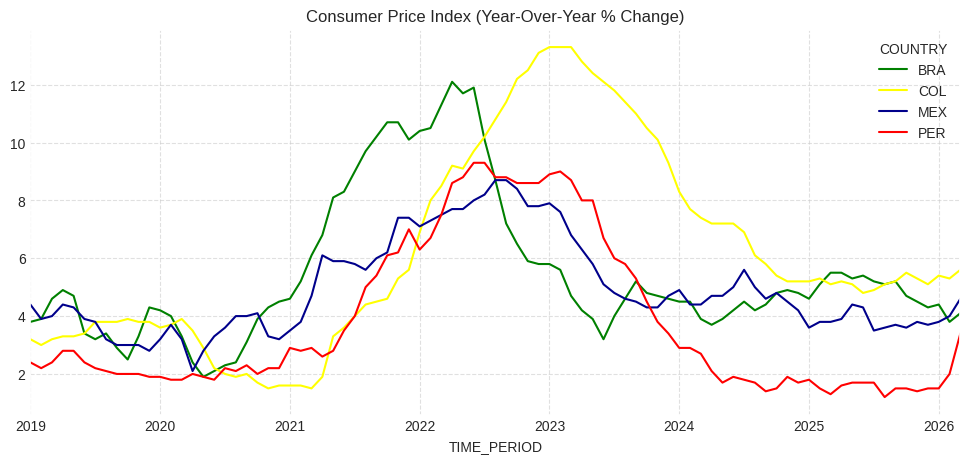

In [11]:
inflation.plot(figsize=(12, 5), title='CPI, one-year percent change',
         color=['green', 'yellow', 'darkblue', 'red']);
plt.title('Consumer Price Index (Year-Over-Year % Change)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()